# 🏨 Hotel Channel Profitability Analysis
## Hypothesis 2: OTA มีอัตราการยกเลิกสูงกว่า → รายได้จริงลดลง & ประสิทธิภาพต้นทุนลดลง

**Hypothesis:** ช่องทาง OTA มีอัตราการยกเลิกการจองสูงกว่า ส่งผลให้รายได้ที่เกิดขึ้นจริงลดลง และทำให้ประสิทธิภาพด้านต้นทุนลดลง

---
### คำถามที่จะตอบ:
- Q3: Cancellation ส่งผลต่อ Net Revenue จริง มากแค่ไหน?
- Q5: Cancellation ส่งผลต่อ average net margin ต่อ booking ที่ "สำเร็จจริง" แค่ไหน?

In [ ]:
# ติดตั้ง library ที่จำเป็น
!pip install openpyxl plotly -q

In [ ]:
# อัปโหลดไฟล์ Excel
from google.colab import files
uploaded = files.upload()  # เลือกไฟล์ hotel_channel_profitability_v2__2_.xlsx

Saving hotel_channel_profitability_v2.xlsx to hotel_channel_profitability_v2.xlsx


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib import rcParams
import warnings
warnings.filterwarnings('ignore')

# ตั้งค่า style
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['figure.dpi'] = 120

# Color palette
COLORS = {
    'OTA':       '#E74C3C',
    'Direct':    '#2ECC71',
    'Corporate': '#3498DB',
    'Offline':   '#F39C12',
    'GDS':       '#9B59B6',
}

print('✅ Libraries loaded')

✅ Libraries loaded


In [ ]:
# โหลดข้อมูล
file_name = list(uploaded.keys())[0]
df = pd.read_excel(file_name, sheet_name='fact_bookingswork H2 (2)')

print(f'📊 Total bookings: {len(df):,}')
print(f'\nStatus breakdown:')
print(df['status'].value_counts().to_string())
print(f'\nChannel type breakdown:')
print(df['channel_type'].value_counts().to_string())

📊 Total bookings: 5,000

Status breakdown:
status
Checked-Out    3273
Cancelled      1014
Confirmed       713

Channel type breakdown:
channel_type
OTA          2796
Direct        959
Corporate     582
Offline       349
GDS           314


In [ ]:
# ==============================================================
# เตรียมข้อมูลระดับ Channel
# ==============================================================
channel_stats = df.groupby(['channel_name', 'channel_type']).agg(
    total_bookings      = ('booking_id', 'count'),
    cancelled           = ('Cancelled Flag', 'sum'),
    checked_out         = ('Checked-Out Flag', 'sum'),
    avg_net_revenue     = ('net_room_revenue', 'mean'),
    total_net_revenue   = ('net_room_revenue', 'sum'),
    avg_gross_revenue   = ('gross_room_revenue', 'mean'),
    total_gross_revenue = ('gross_room_revenue', 'sum'),
    avg_net_margin      = ('net_margin', 'mean'),
    avg_commission      = ('commission_amount', 'mean'),
).reset_index()

channel_stats['cancel_rate']        = channel_stats['cancelled'] / channel_stats['total_bookings']
channel_stats['checkout_rate']      = channel_stats['checked_out'] / channel_stats['total_bookings']
channel_stats['revenue_lost_pct']   = channel_stats['cancelled'] * channel_stats['avg_gross_revenue'] / channel_stats['total_gross_revenue']

# Net revenue เฉพาะ Checked-Out bookings
completed = df[df['Checked-Out Flag'] == 1]
completed_stats = completed.groupby('channel_name').agg(
    avg_net_margin_completed = ('net_margin', 'mean'),
    avg_net_rev_completed    = ('net_room_revenue', 'mean'),
).reset_index()

channel_stats = channel_stats.merge(completed_stats, on='channel_name', how='left')

print('✅ Channel stats prepared')
print(channel_stats[['channel_name','channel_type','cancel_rate','avg_net_margin','avg_net_margin_completed']].to_string(index=False))

✅ Channel stats prepared
    channel_name channel_type  cancel_rate  avg_net_margin  avg_net_margin_completed
           Agoda          OTA     0.223094        1.068488                  1.066835
     Booking.com          OTA     0.296429        1.118487                  1.119846
Corporate Direct    Corporate     0.104811        1.026858                  1.026616
  Direct Website       Direct     0.118890        1.000000                  1.000000
         Expedia          OTA     0.261480        1.149515                  1.154278
   GDS (Amadeus)          GDS     0.181529        1.250000                  1.250000
   Travel Agency      Offline     0.148997        1.111111                  1.111111
         Walk-in       Direct     0.089109        1.000000                  1.000000


---
## 📊 Scatter Plot 1: Cancellation Rate vs Average Net Revenue by Channel
**คำถาม Q3:** Cancellation Rate สูงขึ้น → Net Revenue ลดลงจริงหรือไม่?

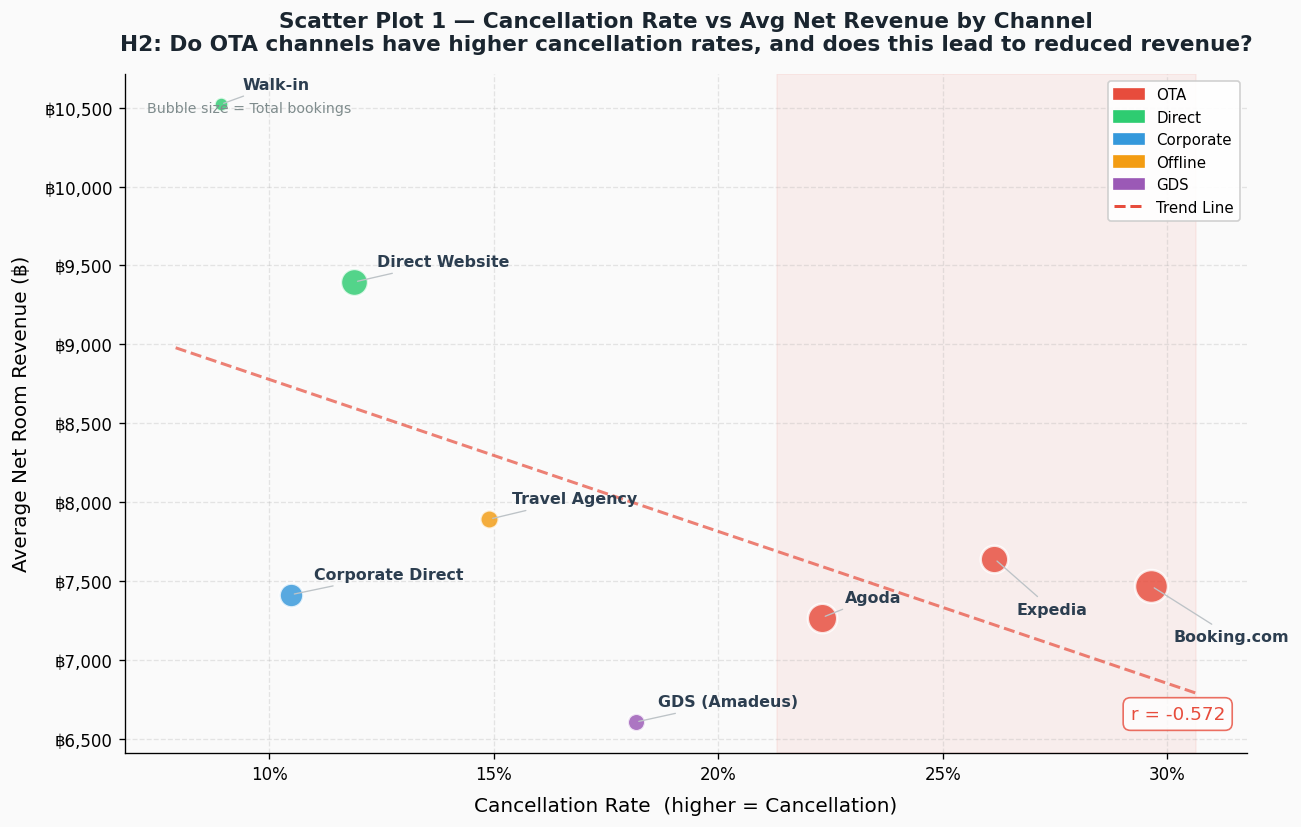

✅ Saved: H2_scatter1_cancel_vs_netrev.png


In [ ]:
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

for _, row in channel_stats.iterrows():
    ctype   = row['channel_type']
    color   = COLORS.get(ctype, '#95A5A6')
    size    = row['total_bookings'] * 0.35

    ax.scatter(
        row['cancel_rate'],
        row['avg_net_revenue'],
        s=size, color=color, alpha=0.82,
        edgecolors='white', linewidths=1.5, zorder=3
    )

    # Label
    offset_x = 0.005
    offset_y = 100 if row['channel_name'] not in ['Booking.com','Expedia'] else -350
    ax.annotate(
        row['channel_name'],
        xy=(row['cancel_rate'], row['avg_net_revenue']),
        xytext=(row['cancel_rate'] + offset_x, row['avg_net_revenue'] + offset_y),
        fontsize=9.5, fontweight='bold', color='#2C3E50',
        arrowprops=dict(arrowstyle='-', color='#BDC3C7', lw=0.8)
    )

# Trend line
x_vals = channel_stats['cancel_rate'].values
y_vals = channel_stats['avg_net_revenue'].values
z = np.polyfit(x_vals, y_vals, 1)
p = np.poly1d(z)
x_line = np.linspace(x_vals.min() - 0.01, x_vals.max() + 0.01, 100)
ax.plot(x_line, p(x_line), '--', color='#E74C3C', lw=1.8, alpha=0.7, label='Trend Line', zorder=2)

# Correlation
corr = np.corrcoef(x_vals, y_vals)[0, 1]
ax.text(0.98, 0.05, f'r = {corr:.3f}', transform=ax.transAxes,
        ha='right', fontsize=11, color='#E74C3C',
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#E74C3C', alpha=0.8))

# OTA region shading
ota_data = channel_stats[channel_stats['channel_type'] == 'OTA']
ax.axvspan(ota_data['cancel_rate'].min() - 0.01, ota_data['cancel_rate'].max() + 0.01,
           alpha=0.07, color='#E74C3C', label='OTA Zone')

# Legend for channel types
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
legend_patches.append(plt.Line2D([0], [0], linestyle='--', color='#E74C3C', lw=1.8, label='Trend Line'))
ax.legend(handles=legend_patches, loc='upper right', framealpha=0.9, fontsize=9)

ax.set_xlabel('Cancellation Rate  (higher = Cancellation)', fontsize=12, labelpad=8)
ax.set_ylabel('Average Net Room Revenue (฿)', fontsize=12, labelpad=8)
ax.set_title(
    'Scatter Plot 1 — Cancellation Rate vs Avg Net Revenue by Channel\n'
    'H2: Do OTA channels have higher cancellation rates, and does this lead to reduced revenue?',#OTA มีอัตราการยกเลิกสูงกว่า → รายได้ลดลงหรือไม่
    fontsize=13, fontweight='bold', pad=14, color='#1A252F'
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'฿{x:,.0f}'))
ax.grid(axis='both', linestyle='--', alpha=0.3, zorder=0)

# Bubble size note
ax.text(0.02, 0.96, 'Bubble size = Total bookings',
        transform=ax.transAxes, fontsize=8.5, color='#7F8C8D', va='top')

plt.tight_layout()
plt.savefig('H2_scatter1_cancel_vs_netrev.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: H2_scatter1_cancel_vs_netrev.png')

---
## 📊 Scatter Plot 2: Cancellation Rate vs Net Margin (All vs Completed only)
**คำถาม Q5:** Cancellation ทำให้ Net Margin ต่อ booking ที่ "สำเร็จจริง" แย่ลงแค่ไหน?

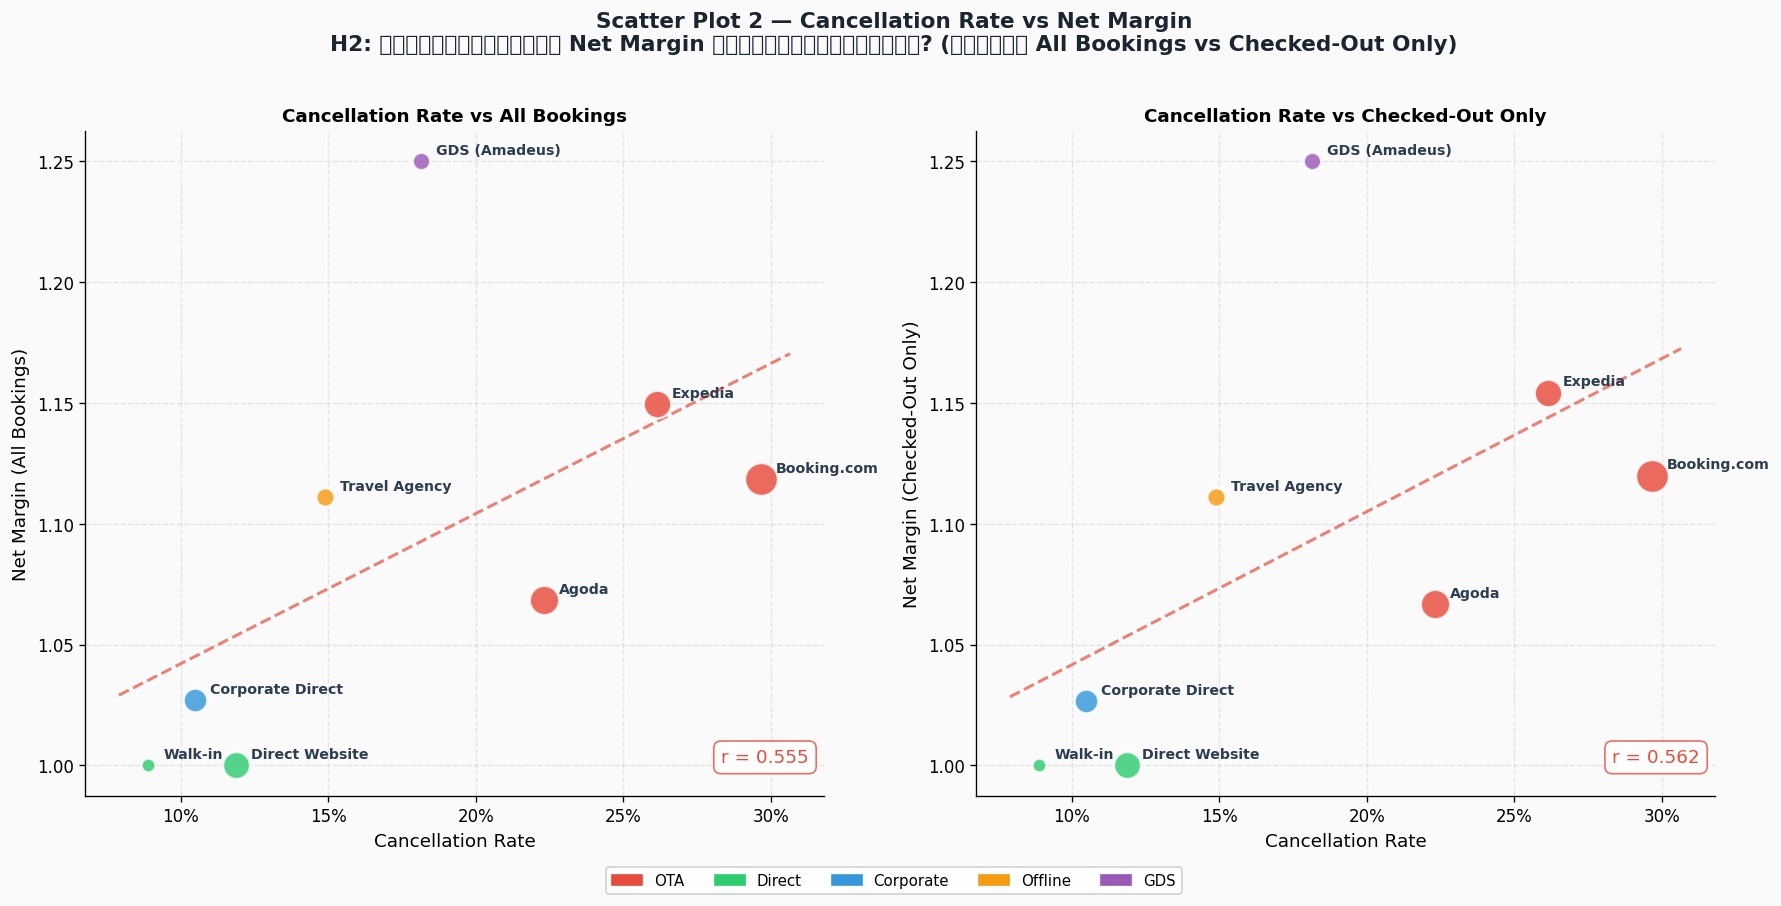

✅ Saved: H2_scatter2_cancel_vs_margin.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharey=False)
fig.patch.set_facecolor('#FAFAFA')

subplot_data = [
    ('avg_net_margin',           'Net Margin (All Bookings)',         'All Bookings'),
    ('avg_net_margin_completed', 'Net Margin (Checked-Out Only)',     'Checked-Out Only'),
]

for ax, (ycol, ylabel, subtitle) in zip(axes, subplot_data):
    ax.set_facecolor('#FAFAFA')

    for _, row in channel_stats.iterrows():
        ctype = row['channel_type']
        color = COLORS.get(ctype, '#95A5A6')
        size  = row['total_bookings'] * 0.35

        ax.scatter(
            row['cancel_rate'], row[ycol],
            s=size, color=color, alpha=0.82,
            edgecolors='white', linewidths=1.5, zorder=3
        )
        ax.annotate(
            row['channel_name'],
            xy=(row['cancel_rate'], row[ycol]),
            xytext=(row['cancel_rate'] + 0.005, row[ycol] + 0.003),
            fontsize=8.5, fontweight='bold', color='#2C3E50',
        )

    # Trend
    x_vals = channel_stats['cancel_rate'].values
    y_vals = channel_stats[ycol].values
    z = np.polyfit(x_vals, y_vals, 1)
    p = np.poly1d(z)
    x_line = np.linspace(x_vals.min() - 0.01, x_vals.max() + 0.01, 100)
    ax.plot(x_line, p(x_line), '--', color='#E74C3C', lw=1.8, alpha=0.7)

    corr = np.corrcoef(x_vals, y_vals)[0, 1]
    ax.text(0.98, 0.05, f'r = {corr:.3f}', transform=ax.transAxes,
            ha='right', fontsize=11, color='#E74C3C',
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='#E74C3C', alpha=0.8))

    ax.set_xlabel('Cancellation Rate', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(f'Cancellation Rate vs {subtitle}', fontsize=11, fontweight='bold')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.grid(axis='both', linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Shared legend
legend_patches = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
fig.legend(handles=legend_patches, loc='lower center', ncol=5, fontsize=9,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.04))

fig.suptitle(
    'Scatter Plot 2 — Cancellation Rate vs Net Margin\n'
    'H2: การยกเลิกทำให้ Net Margin ต่ำลงจริงหรือไม่? (เปรียบ All Bookings vs Checked-Out Only)',
    fontsize=13, fontweight='bold', y=1.02, color='#1A252F'
)
plt.tight_layout()
plt.savefig('H2_scatter2_cancel_vs_margin.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: H2_scatter2_cancel_vs_margin.png')

---
## 📊 Scatter Plot 3: Booking-Level — OTA vs Non-OTA Cancellation & Net Revenue
**มุมมอง individual booking:** OTA bookings ที่ถูกยกเลิก มี pattern ต่างกับ Non-OTA อย่างไร?

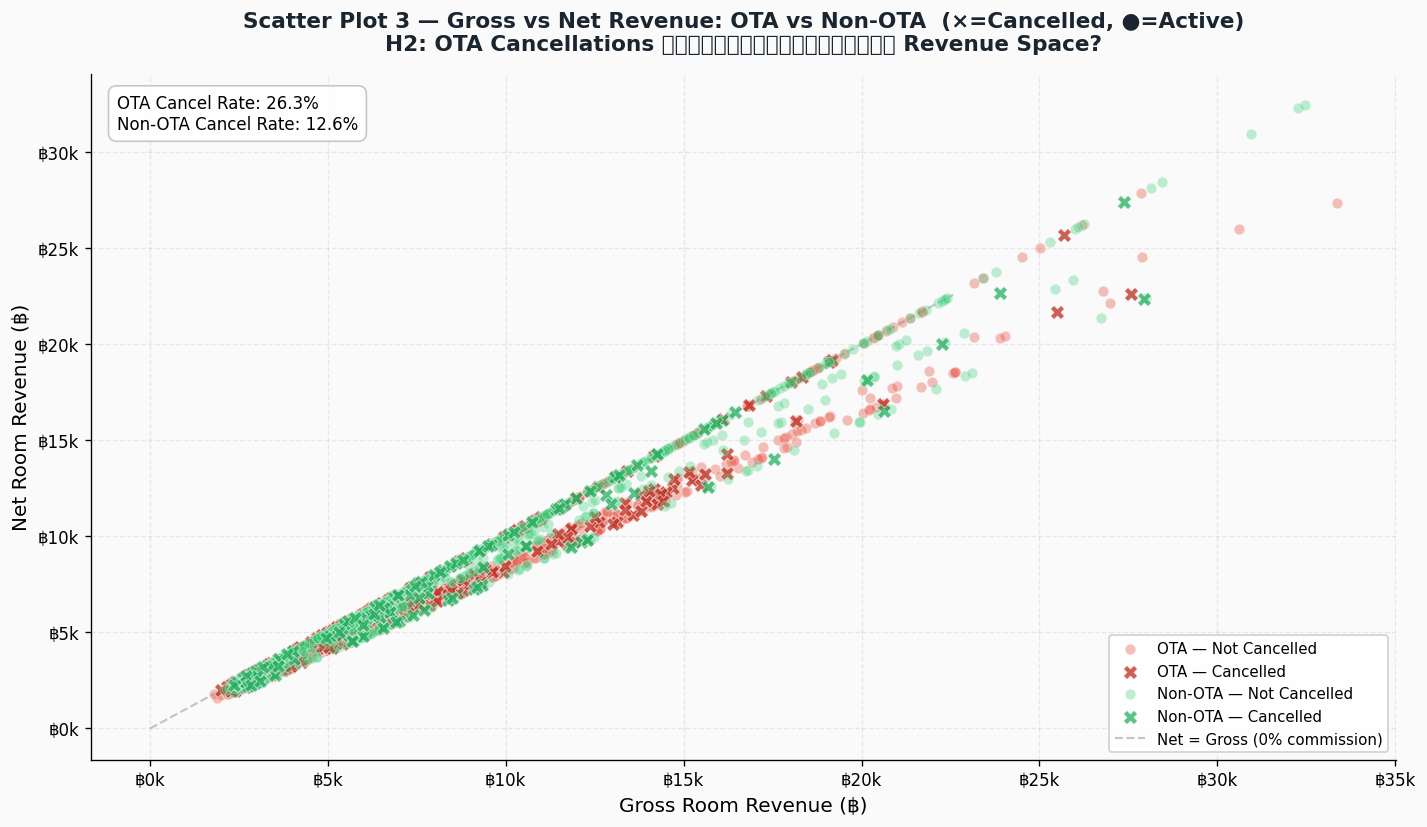

✅ Saved: H2_scatter3_gross_vs_net_ota.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

# Sample for readability
df_sample = df.sample(min(2000, len(df)), random_state=42).copy()
df_sample['is_ota'] = df_sample['channel_type'] == 'OTA'

plot_groups = [
    (df_sample[(df_sample['is_ota'] == True)  & (df_sample['Cancelled Flag'] == 0)],
     '#E74C3C', 'o', 0.35, 40, 'OTA — Not Cancelled'),
    (df_sample[(df_sample['is_ota'] == True)  & (df_sample['Cancelled Flag'] == 1)],
     '#C0392B', 'X', 0.80, 70, 'OTA — Cancelled'),
    (df_sample[(df_sample['is_ota'] == False) & (df_sample['Cancelled Flag'] == 0)],
     '#2ECC71', 'o', 0.30, 40, 'Non-OTA — Not Cancelled'),
    (df_sample[(df_sample['is_ota'] == False) & (df_sample['Cancelled Flag'] == 1)],
     '#27AE60', 'X', 0.75, 70, 'Non-OTA — Cancelled'),
]

for data, color, marker, alpha, size, label in plot_groups:
    ax.scatter(
        data['gross_room_revenue'],
        data['net_room_revenue'],
        c=color, marker=marker, alpha=alpha, s=size,
        edgecolors='white', linewidths=0.4, label=label, zorder=3
    )

# Diagonal reference line (net = gross, no commission)
max_val = df_sample['gross_room_revenue'].quantile(0.98)
ax.plot([0, max_val], [0, max_val], '--', color='#95A5A6', lw=1.3, alpha=0.6, label='Net = Gross (0% commission)')

ax.set_xlabel('Gross Room Revenue (฿)', fontsize=12)
ax.set_ylabel('Net Room Revenue (฿)', fontsize=12)
ax.set_title(
    'Scatter Plot 3 — Gross vs Net Revenue: OTA vs Non-OTA  (×=Cancelled, ●=Active)\n'
    'H2: OTA Cancellations กระจายตัวอย่างไรใน Revenue Space?',
    fontsize=13, fontweight='bold', pad=14, color='#1A252F'
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'฿{x/1000:.0f}k'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'฿{x/1000:.0f}k'))
ax.legend(fontsize=9, framealpha=0.9)
ax.grid(axis='both', linestyle='--', alpha=0.25, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Annotation: cancellation stats
ota_cancel_rate    = df[df['channel_type']=='OTA']['Cancelled Flag'].mean()
nonota_cancel_rate = df[df['channel_type']!='OTA']['Cancelled Flag'].mean()
ax.text(0.02, 0.97,
    f'OTA Cancel Rate: {ota_cancel_rate:.1%}\nNon-OTA Cancel Rate: {nonota_cancel_rate:.1%}',
    transform=ax.transAxes, va='top', fontsize=10,
    bbox=dict(boxstyle='round,pad=0.5', fc='white', ec='#BDC3C7', alpha=0.9)
)

plt.tight_layout()
plt.savefig('H2_scatter3_gross_vs_net_ota.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: H2_scatter3_gross_vs_net_ota.png')

---
## 📊 Scatter Plot 4: Revenue Lost from Cancellation vs Checkout Rate (Channel Level)
**สรุปภาพรวม:** Channel ที่ Checkout Rate ต่ำ สูญเสีย Revenue มากแค่ไหน?

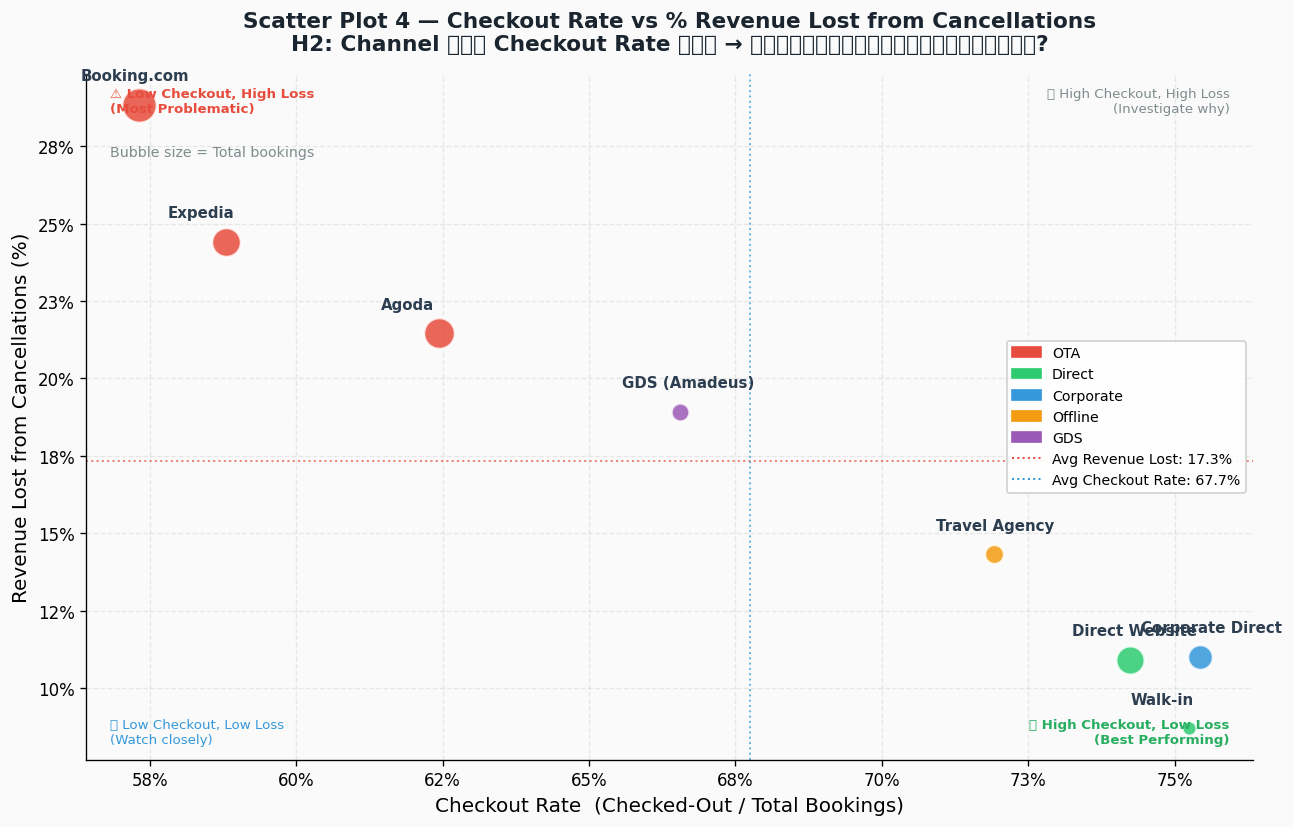

✅ Saved: H2_scatter4_checkout_vs_revlost.png


In [ ]:
# คำนวณ revenue lost
def calc_revenue_lost(group):
    cancelled    = group[group['Cancelled Flag'] == 1]['gross_room_revenue'].sum()
    total_gross  = group['gross_room_revenue'].sum()
    return cancelled / total_gross if total_gross > 0 else 0

rev_lost = df.groupby(['channel_name','channel_type']).apply(calc_revenue_lost).reset_index()
rev_lost.columns = ['channel_name','channel_type','revenue_lost_pct']

plot_df = channel_stats.merge(rev_lost, on=['channel_name','channel_type'])

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

for _, row in plot_df.iterrows():
    ctype = row['channel_type']
    color = COLORS.get(ctype, '#95A5A6')
    size  = row['total_bookings'] * 0.4

    ax.scatter(
        row['checkout_rate'],
        row['revenue_lost_pct_y'],
        s=size, color=color, alpha=0.85,
        edgecolors='white', linewidths=1.8, zorder=3
    )
    ax.annotate(
        row['channel_name'],
        xy=(row['checkout_rate'], row['revenue_lost_pct_y']),
        xytext=(row['checkout_rate'] - 0.01, row['revenue_lost_pct_y'] + 0.008),
        fontsize=9, fontweight='bold', color='#2C3E50',
    )

# Quadrant lines
ax.axhline(y=plot_df['revenue_lost_pct_y'].mean(), color='#E74C3C', lw=1.2,
           linestyle=':', alpha=0.7, label=f'Avg Revenue Lost: {plot_df["revenue_lost_pct_y"].mean():.1%}')
ax.axvline(x=plot_df['checkout_rate'].mean(), color='#3498DB', lw=1.2,
           linestyle=':', alpha=0.7, label=f'Avg Checkout Rate: {plot_df["checkout_rate"].mean():.1%}')

# Quadrant labels
ax.text(0.98, 0.98, '🔴 High Checkout, High Loss\n(Investigate why)', transform=ax.transAxes,
        ha='right', va='top', fontsize=8, color='#7F8C8D')
ax.text(0.02, 0.98, '⚠️ Low Checkout, High Loss\n(Most Problematic)', transform=ax.transAxes,
        ha='left', va='top', fontsize=8, color='#E74C3C', fontweight='bold')
ax.text(0.98, 0.02, '✅ High Checkout, Low Loss\n(Best Performing)', transform=ax.transAxes,
        ha='right', va='bottom', fontsize=8, color='#27AE60', fontweight='bold')
ax.text(0.02, 0.02, '🔵 Low Checkout, Low Loss\n(Watch closely)', transform=ax.transAxes,
        ha='left', va='bottom', fontsize=8, color='#3498DB')

legend_patches = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
legend_patches += [
    plt.Line2D([0],[0], color='#E74C3C', lw=1.2, linestyle=':', label=f'Avg Revenue Lost: {plot_df["revenue_lost_pct_y"].mean():.1%}'),
    plt.Line2D([0],[0], color='#3498DB', lw=1.2, linestyle=':', label=f'Avg Checkout Rate: {plot_df["checkout_rate"].mean():.1%}'),
]
ax.legend(handles=legend_patches, fontsize=8.5, framealpha=0.9, loc='center right')

ax.set_xlabel('Checkout Rate  (Checked-Out / Total Bookings)', fontsize=12)
ax.set_ylabel('Revenue Lost from Cancellations (%)', fontsize=12)
ax.set_title(
    'Scatter Plot 4 — Checkout Rate vs % Revenue Lost from Cancellations\n'
    'H2: Channel ที่ Checkout Rate ต่ำ → สูญเสียรายได้มากแค่ไหน?',
    fontsize=13, fontweight='bold', pad=14, color='#1A252F'
)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.grid(axis='both', linestyle='--', alpha=0.25, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.text(0.02, 0.88, 'Bubble size = Total bookings',
        transform=ax.transAxes, fontsize=8.5, color='#7F8C8D')

plt.tight_layout()
plt.savefig('H2_scatter4_checkout_vs_revlost.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: H2_scatter4_checkout_vs_revlost.png')

---
## 📋 Summary Statistics: Hypothesis 2

In [ ]:
print('=' * 70)
print('HYPOTHESIS 2 SUMMARY — OTA มีอัตราการยกเลิกสูงกว่า → รายได้ลดลง')
print('=' * 70)

# OTA vs Non-OTA cancellation
ota    = df[df['channel_type'] == 'OTA']
nonota = df[df['channel_type'] != 'OTA']

print(f'\n📌 Cancellation Rate:')
print(f'   OTA channels    : {ota["Cancelled Flag"].mean():.1%}')
print(f'   Non-OTA channels: {nonota["Cancelled Flag"].mean():.1%}')
print(f'   Difference      : {(ota["Cancelled Flag"].mean() - nonota["Cancelled Flag"].mean()):.1%} pp')

print(f'\n📌 Average Net Revenue (Checked-Out bookings only):')
ota_co    = ota[ota['Checked-Out Flag'] == 1]
nonota_co = nonota[nonota['Checked-Out Flag'] == 1]
print(f'   OTA    : ฿{ota_co["net_room_revenue"].mean():,.0f}')
print(f'   Non-OTA: ฿{nonota_co["net_room_revenue"].mean():,.0f}')

print(f'\n📌 Total Revenue Lost to Cancellations:')
ota_lost    = ota[ota['Cancelled Flag'] == 1]['gross_room_revenue'].sum()
nonota_lost = nonota[nonota['Cancelled Flag'] == 1]['gross_room_revenue'].sum()
print(f'   OTA    : ฿{ota_lost:,.0f}')
print(f'   Non-OTA: ฿{nonota_lost:,.0f}')
print(f'   Total  : ฿{ota_lost + nonota_lost:,.0f}')

print(f'\n📌 Net Margin — All Bookings vs Checked-Out Only:')
for ctype in ['OTA','Direct','Corporate','Offline','GDS']:
    grp  = df[df['channel_type'] == ctype]
    grp_co = grp[grp['Checked-Out Flag'] == 1]
    if len(grp) > 0:
        print(f'   {ctype:<12} All: {grp["net_margin"].mean():.4f}  |  Checked-Out: {grp_co["net_margin"].mean():.4f}')

print(f'\n✅ Conclusion:')
ota_cancel = ota['Cancelled Flag'].mean()
noa_cancel = nonota['Cancelled Flag'].mean()
if ota_cancel > noa_cancel:
    print(f'   H2 SUPPORTED — OTA cancel rate ({ota_cancel:.1%}) > Non-OTA ({noa_cancel:.1%})')
    print(f'   Revenue leakage from OTA cancellations: ฿{ota_lost:,.0f}')
else:
    print(f'   H2 NOT SUPPORTED — OTA cancel rate ({ota_cancel:.1%}) is NOT higher than Non-OTA ({noa_cancel:.1%})')

HYPOTHESIS 2 SUMMARY — OTA มีอัตราการยกเลิกสูงกว่า → รายได้ลดลง

📌 Cancellation Rate:
   OTA channels    : 26.3%
   Non-OTA channels: 12.6%
   Difference      : 13.7% pp

📌 Average Net Revenue (Checked-Out bookings only):
   OTA    : ฿7,559
   Non-OTA: ฿8,367

📌 Total Revenue Lost to Cancellations:
   OTA    : ฿5,824,566
   Non-OTA: ฿2,378,366
   Total  : ฿8,202,932

📌 Net Margin — All Bookings vs Checked-Out Only:
   OTA          All: 1.1112  |  Checked-Out: 1.1116
   Direct       All: 1.0000  |  Checked-Out: 1.0000
   Corporate    All: 1.0269  |  Checked-Out: 1.0266
   Offline      All: 1.1111  |  Checked-Out: 1.1111
   GDS          All: 1.2500  |  Checked-Out: 1.2500

✅ Conclusion:
   H2 SUPPORTED — OTA cancel rate (26.3%) > Non-OTA (12.6%)
   Revenue leakage from OTA cancellations: ฿5,824,566


correration


---
## 💾 Download All Charts

In [ ]:
import zipfile, os
from google.colab import files

chart_files = [
    'H2_scatter1_cancel_vs_netrev.png',
    'H2_scatter2_cancel_vs_margin.png',
    'H2_scatter3_gross_vs_net_ota.png',
    'H2_scatter4_checkout_vs_revlost.png',
]

with zipfile.ZipFile('H2_scatter_plots.zip', 'w') as zf:
    for f in chart_files:
        if os.path.exists(f):
            zf.write(f)
            print(f'  Added: {f}')

files.download('H2_scatter_plots.zip')
print('\n✅ Download started!')

  Added: H2_scatter1_cancel_vs_netrev.png
  Added: H2_scatter2_cancel_vs_margin.png
  Added: H2_scatter3_gross_vs_net_ota.png
  Added: H2_scatter4_checkout_vs_revlost.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Download started!
